<a href="https://colab.research.google.com/github/sr606/Python-Practice/blob/main/Mermaid10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
✅ Column-level aware

✅ Join column mapping visible

✅ Smart section skipping

✅ No artificial truncation

✅ Clean rendering

✅ With full DOT printed to console

✅ Chunk-safe

Below is your complete upgraded architecture + updated scripts.

🏗 UPDATED ARCHITECTURE
agent.py
│
├── parsing/
│     ├── parser.py
│     ├── extractor.py
│     └── lineage_order.py
│
├── llm/
│     ├── llm_normalizer.py   ← upgraded
│     └── llm_dot_compiler.py ← upgraded
│
└── rendering/
      └── dot_sanitizer.py
🔥 1️⃣ UPDATE: llm_normalizer.py

We will:

Extract join column pairs

Detect null handling

Detect CASE derivations

Preserve full logic

Deduplicate cleanly

✅ REPLACE extract_joins() WITH THIS
def extract_join_columns(condition):
    """
    Extract column pairs from join condition
    Example:
    vor.registration_number = v.registration_no
    """
    pairs = re.findall(
        r"([a-zA-Z0-9_\.]+)\s*=\s*([a-zA-Z0-9_\.]+)",
        condition
    )
    return pairs


def extract_joins(sql_text):
    if not sql_text:
        return []

    join_pattern = re.findall(
        r"""
        \b
        (LEFT|RIGHT|INNER|FULL)?      # Join type
        \s*
        (OUTER\s+)?
        JOIN
        \s+
        (
            \([^\)]*?\)
            |
            [a-zA-Z0-9_\.]+
        )
        \s+
        .*?
        \bON\b
        \s+
        (.*?)
        (?=
            \bLEFT\b|
            \bRIGHT\b|
            \bINNER\b|
            \bFULL\b|
            \bWHERE\b|
            \bGROUP\b|
            \bORDER\b|
            $
        )
        """,
        sql_text,
        re.IGNORECASE | re.DOTALL | re.VERBOSE
    )

    joins = []

    for jt, outer, table, condition in join_pattern:
        join_type = (jt.upper() if jt else "JOIN") + " JOIN"

        joins.append({
            "join_type": join_type,
            "table": table.strip(),
            "condition": condition.strip(),
            "columns": extract_join_columns(condition)
        })

    return joins
✅ UPDATE extract_transformations()

Replace with:

def extract_transformations(transform_text):
    results = []

    for line in transform_text.split("\n"):
        line = line.strip()

        if "=" in line and not line.startswith("--"):
            parts = line.split("=", 1)

            target = parts[0].strip()
            logic = parts[1].strip()

            t_type = "DIRECT"

            if "NVL(" in logic.upper():
                t_type = "NULL_HANDLING"
            elif "CASE" in logic.upper():
                t_type = "DERIVATION"

            results.append({
                "target": target,
                "logic": logic,
                "type": t_type
            })

    return results
🔥 2️⃣ UPDATE: llm_dot_compiler.py

We now:

Remove truncation

Dynamically skip empty sections

Show join column mappings

Show transformation source → target

Print full DOT

✅ REPLACE generate_dot() WITH THIS
def generate_dot(workflow_name, stages):

    # DO NOT TRUNCATE ANYTHING
    minimal_stages = []

    for s in stages:
        minimal_stages.append({
            "stage_id": s["stage_id"],
            "inputs": s.get("inputs", []),
            "outputs": s.get("outputs", []),
            "primary_tables": s.get("primary_tables", []),
            "joins": s.get("joins", []),
            "filters": s.get("filters", []),
            "transformations": s.get("transformations", [])
        })

    payload = json.dumps({
        "workflow_name": workflow_name,
        "stages": minimal_stages
    }, ensure_ascii=False)

    enhanced_prompt = PROMPT + """

SMART RULES:

- If primary_tables empty → DO NOT render section
- If joins empty → DO NOT render section
- If transformations empty → DO NOT render section

JOINS SECTION:
For each join:
• Show join type
• Show table name
• Show column pairs like:
    columnA = columnB

TRANSFORMATIONS SECTION:
For each transformation:
• Show: target ← logic
• If type = NULL_HANDLING, prefix with (Null Handling)
• If type = DERIVATION, prefix with (Derived)

Do NOT truncate.
Do NOT hallucinate.
Do NOT add markdown.
"""

    response = client.chat.completions.create(
        model=AZURE_OPENAI_DEPLOYMENT,
        temperature=0,
        messages=[
            {"role": "system", "content": "You generate strictly valid Graphviz DOT."},
            {"role": "user", "content": enhanced_prompt + "\n\nWorkflow JSON:\n" + payload}
        ]
    )

    dot_output = response.choices[0].message.content.strip()

    print("\n================ FULL DOT OUTPUT ================")
    print(dot_output)
    print("=================================================\n")

    return dot_output
🔥 3️⃣ UPDATE agent.py (Print DOT Before Render)

Inside process_file() change:

dot_code = generate_dot(workflow_name, structured_stages)

dot_code = clean_and_validate_dot(dot_code)

To:

dot_code = generate_dot(workflow_name, structured_stages)

print("\n=========== CLEANED DOT ===========")
print(dot_code)
print("===================================\n")

dot_code = clean_and_validate_dot(dot_code)
🔥 4️⃣ OPTIONAL: Improve DOT PROMPT Header

Replace your existing PROMPT with this improved version:

PROMPT = """
You are a professional ETL lineage Graphviz compiler.

Generate COMPLETE valid DOT code.

STRICT RULES:

- rankdir=LR
- bgcolor="white"
- node [shape=plain, fontname="Helvetica"]
- Use subgraph cluster_workflow
- Do NOT use markdown
- Do NOT use ```
- Do NOT rename stage_id
- Do NOT remove any joins or transformations
- Skip empty sections automatically

Node format must use table HTML style.

Output must start with:

digraph WORKFLOW_NAME {
"""
🎯 WHAT YOU WILL NOW SEE

Each stage will look like:

ORA_Ext_Vehicle_Off_Road_Data

Primary Tables
• supplierdata_ext.vor_vehicle_off_road

Joins
• LEFT JOIN vehicle_dim
  registration_number = registration_no

Transformations
• (Null Handling) ORIGINAL_WORKSHEET_NUMBER ← NVL(...)
• (Derived) SUPP_SK ← CASE WHEN ...

If no joins → joins section omitted
If no transformations → transformations section omitted

Clean. Intelligent. Professional.

🚀 WHAT THIS GIVES YOU

✔ Full SQL preserved
✔ Join column mapping
✔ Null handling labeled
✔ Derived columns labeled
✔ No truncation
✔ Dynamic clean layout
✔ Full DOT printed for debugging
✔ Ready for enterprise lineage

🧠 Next Step

Run this on your heavy ORA SQL stage.

If DOT is too large, next enhancement:

Auto-chunk stage-level rendering

Or collapse repeated joins

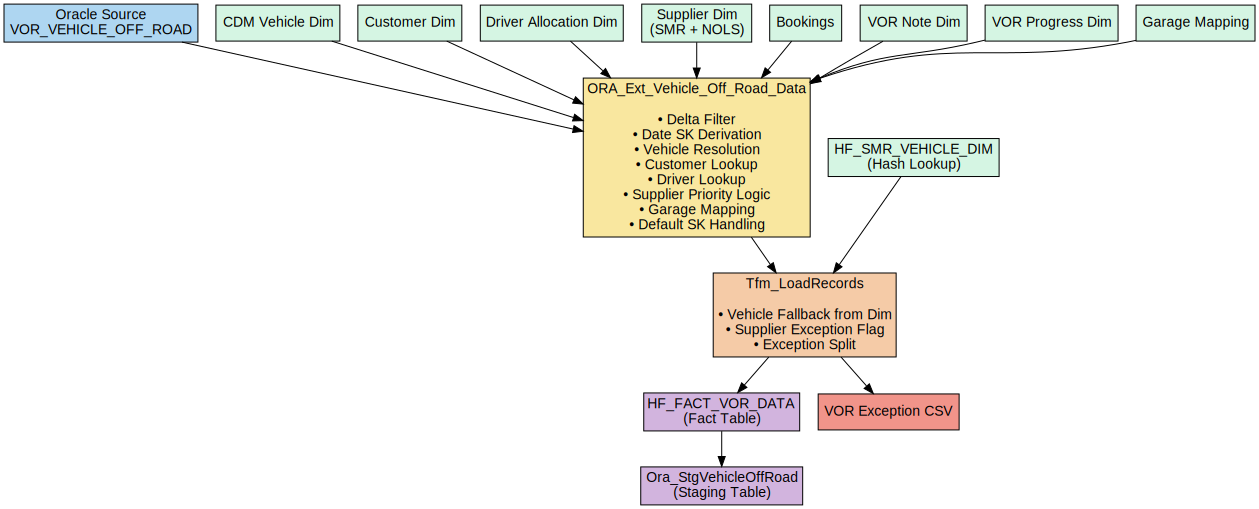

In [2]:
import graphviz

dot_code = """
digraph VOR_Lineage {

    rankdir=TB;
    node [shape=box, style=filled, fontname="Helvetica"];

    /* ============================= */
    /*           SOURCES             */
    /* ============================= */

    ORA_VOR [label="Oracle Source\nVOR_VEHICLE_OFF_ROAD", fillcolor="#AED6F1"];

    VEHICLE_DIM [label="CDM Vehicle Dim", fillcolor="#D5F5E3"];
    CUSTOMER_DIM [label="Customer Dim", fillcolor="#D5F5E3"];
    DRIVER_ALLOC [label="Driver Allocation Dim", fillcolor="#D5F5E3"];
    SUPPLIER_DIM [label="Supplier Dim\n(SMR + NOLS)", fillcolor="#D5F5E3"];
    BOOKINGS [label="Bookings", fillcolor="#D5F5E3"];
    VOR_NOTE [label="VOR Note Dim", fillcolor="#D5F5E3"];
    VOR_PROGRESS [label="VOR Progress Dim", fillcolor="#D5F5E3"];
    GARAGE_MAP [label="Garage Mapping", fillcolor="#D5F5E3"];

    /* ============================= */
    /*      EXTRACTION STAGE         */
    /* ============================= */

    EXT_STAGE [label="ORA_Ext_Vehicle_Off_Road_Data\n\n• Delta Filter\n• Date SK Derivation\n• Vehicle Resolution\n• Customer Lookup\n• Driver Lookup\n• Supplier Priority Logic\n• Garage Mapping\n• Default SK Handling",
               fillcolor="#F9E79F"];

    /* ============================= */
    /*       TRANSFORM STAGE         */
    /* ============================= */

    TFM_STAGE [label="Tfm_LoadRecords\n\n• Vehicle Fallback from Dim\n• Supplier Exception Flag\n• Exception Split",
               fillcolor="#F5CBA7"];

    /* ============================= */
    /*          TARGETS              */
    /* ============================= */

    HF_FACT [label="HF_FACT_VOR_DATA\n(Fact Table)", fillcolor="#D2B4DE"];

    STG_TABLE [label="Ora_StgVehicleOffRoad\n(Staging Table)", fillcolor="#D2B4DE"];

    EXCEPTION_FILE [label="VOR Exception CSV", fillcolor="#F1948A"];

    VEH_DIM_HASH [label="HF_SMR_VEHICLE_DIM\n(Hash Lookup)", fillcolor="#D5F5E3"];


    /* ============================= */
    /*         DATA FLOW             */
    /* ============================= */

    ORA_VOR -> EXT_STAGE;

    VEHICLE_DIM -> EXT_STAGE;
    CUSTOMER_DIM -> EXT_STAGE;
    DRIVER_ALLOC -> EXT_STAGE;
    SUPPLIER_DIM -> EXT_STAGE;
    BOOKINGS -> EXT_STAGE;
    VOR_NOTE -> EXT_STAGE;
    VOR_PROGRESS -> EXT_STAGE;
    GARAGE_MAP -> EXT_STAGE;

    EXT_STAGE -> TFM_STAGE;

    VEH_DIM_HASH -> TFM_STAGE;

    TFM_STAGE -> HF_FACT;
    HF_FACT -> STG_TABLE;

    TFM_STAGE -> EXCEPTION_FILE;
}
"""

graphviz.Source(dot_code)

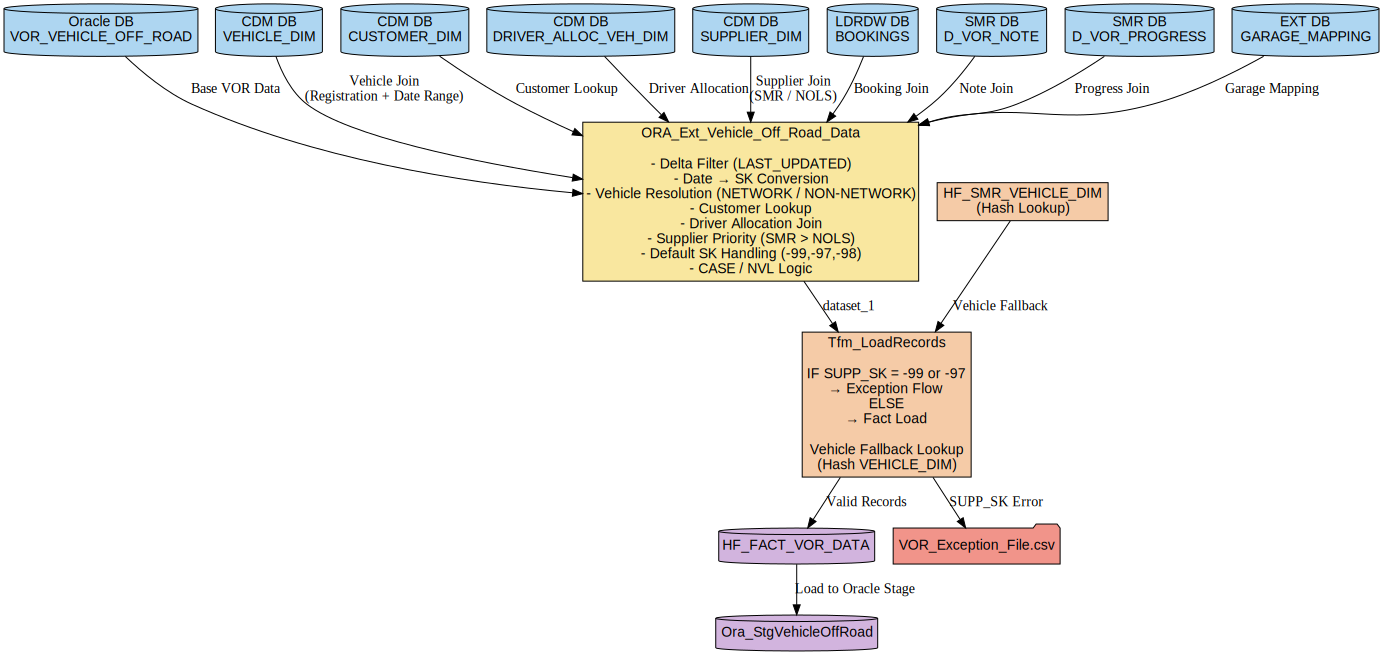

In [4]:
import graphviz

dot_code_2 = """
digraph VOR_Pipeline {

    rankdir=TB;
    fontname="Helvetica";
    node [fontname="Helvetica"];

    /* ========================== */
    /*         DATABASES          */
    /* ========================== */

    node [shape=cylinder, style=filled, fillcolor="#AED6F1"];
    SRC_DB [label="Oracle DB\nVOR_VEHICLE_OFF_ROAD"];
    VEH_DIM [label="CDM DB\nVEHICLE_DIM"];
    CUST_DIM [label="CDM DB\nCUSTOMER_DIM"];
    DRIVER_DIM [label="CDM DB\nDRIVER_ALLOC_VEH_DIM"];
    SUPP_DIM [label="CDM DB\nSUPPLIER_DIM"];
    BOOKINGS_DB [label="LDRDW DB\nBOOKINGS"];
    NOTE_DIM [label="SMR DB\nD_VOR_NOTE"];
    PROG_DIM [label="SMR DB\nD_VOR_PROGRESS"];
    GARAGE_MAP [label="EXT DB\nGARAGE_MAPPING"];

    /* ========================== */
    /*     EXTRACTION LAYER       */
    /* ========================== */

    node [shape=box, style=filled, fillcolor="#F9E79F"];
    EXT_STAGE [label="ORA_Ext_Vehicle_Off_Road_Data\n\n- Delta Filter (LAST_UPDATED)\n- Date → SK Conversion\n- Vehicle Resolution (NETWORK / NON-NETWORK)\n- Customer Lookup\n- Driver Allocation Join\n- Supplier Priority (SMR > NOLS)\n- Default SK Handling (-99,-97,-98)\n- CASE / NVL Logic"];

    /* ========================== */
    /*      TRANSFORM LAYER       */
    /* ========================== */

    node [shape=box, style=filled, fillcolor="#F5CBA7"];
    TFM_STAGE [label="Tfm_LoadRecords\n\nIF SUPP_SK = -99 or -97\n → Exception Flow\nELSE\n → Fact Load\n\nVehicle Fallback Lookup\n(Hash VEHICLE_DIM)"];

    VEH_HASH [label="HF_SMR_VEHICLE_DIM\n(Hash Lookup)"];

    /* ========================== */
    /*         TARGET DB          */
    /* ========================== */

    node [shape=cylinder, style=filled, fillcolor="#D2B4DE"];
    FACT_HASH [label="HF_FACT_VOR_DATA"];
    STG_TABLE [label="Ora_StgVehicleOffRoad"];

    /* ========================== */
    /*         FILE OUTPUT        */
    /* ========================== */

    node [shape=folder, style=filled, fillcolor="#F1948A"];
    EXCEPTION_FILE [label="VOR_Exception_File.csv"];

    /* ========================== */
    /*          FLOWS             */
    /* ========================== */

    /* Source Feeds */
    SRC_DB -> EXT_STAGE [label="Base VOR Data"];
    VEH_DIM -> EXT_STAGE [label="Vehicle Join\n(Registration + Date Range)"];
    CUST_DIM -> EXT_STAGE [label="Customer Lookup"];
    DRIVER_DIM -> EXT_STAGE [label="Driver Allocation"];
    SUPP_DIM -> EXT_STAGE [label="Supplier Join\n(SMR / NOLS)"];
    BOOKINGS_DB -> EXT_STAGE [label="Booking Join"];
    NOTE_DIM -> EXT_STAGE [label="Note Join"];
    PROG_DIM -> EXT_STAGE [label="Progress Join"];
    GARAGE_MAP -> EXT_STAGE [label="Garage Mapping"];

    /* Extraction to Transform */
    EXT_STAGE -> TFM_STAGE [label="dataset_1"];

    /* Hash Lookup */
    VEH_HASH -> TFM_STAGE [label="Vehicle Fallback"];

    /* Main Fact Load */
    TFM_STAGE -> FACT_HASH [label="Valid Records"];
    FACT_HASH -> STG_TABLE [label="Load to Oracle Stage"];

    /* Exception Flow */
    TFM_STAGE -> EXCEPTION_FILE [label="SUPP_SK Error"];
}
"""

graphviz.Source(dot_code_2)

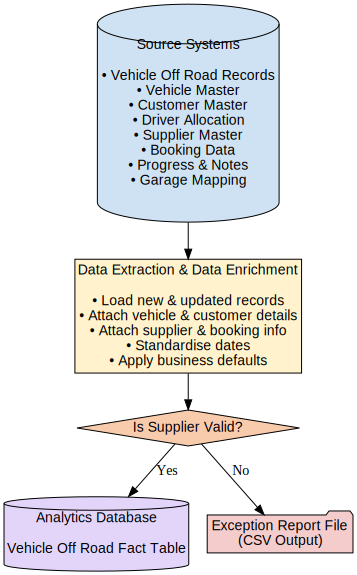

In [6]:
import graphviz

dot_code_3 = """
digraph VOR_Business_View {

    rankdir=TB;
    fontname="Helvetica";
    fontsize=10;
    node [fontname="Helvetica"];

    /* =======================
       SOURCE SYSTEMS
    ======================= */

    node [shape=cylinder, style=filled, fillcolor="#CFE2F3"];
    SOURCES [label="Source Systems\n\n• Vehicle Off Road Records\n• Vehicle Master\n• Customer Master\n• Driver Allocation\n• Supplier Master\n• Booking Data\n• Progress & Notes\n• Garage Mapping"];

    /* =======================
       DATA PROCESSING
    ======================= */

    node [shape=box, style=filled, fillcolor="#FFF2CC"];
    EXTRACTION [label="Data Extraction & Data Enrichment\n\n• Load new & updated records\n• Attach vehicle & customer details\n• Attach supplier & booking info\n• Standardise dates\n• Apply business defaults"];

    /* =======================
       BUSINESS RULE
    ======================= */

    node [shape=diamond, style=filled, fillcolor="#F8CBAD"];
    DECISION [label="Is Supplier Valid?"];

    /* =======================
       TARGET SYSTEM
    ======================= */

    node [shape=cylinder, style=filled, fillcolor="#E2D5F9"];
    FACT_DB [label="Analytics Database\n\nVehicle Off Road Fact Table"];

    /* =======================
       EXCEPTION OUTPUT
    ======================= */

    node [shape=folder, style=filled, fillcolor="#F4CCCC"];
    EXCEPTION_FILE [label="Exception Report File\n(CSV Output)"];

    /* =======================
       FLOW
    ======================= */

    SOURCES -> EXTRACTION;
    EXTRACTION -> DECISION;

    DECISION -> FACT_DB [label="Yes"];
    DECISION -> EXCEPTION_FILE [label="No"];
}
"""

graphviz.Source(dot_code_3)

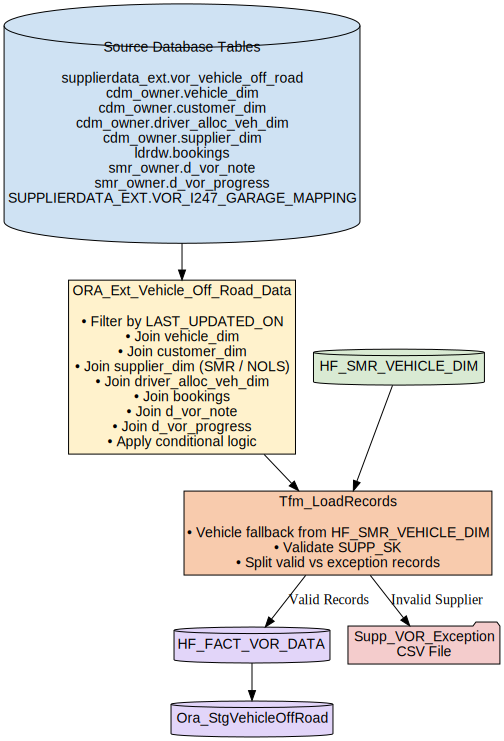

In [8]:
import graphviz

dot_code_4 = """
digraph VOR_Business_Architecture {

    rankdir=TB;
    fontname="Helvetica";
    fontsize=10;
    node [fontname="Helvetica"];

    /* =========================
       SOURCE DATABASE
    ========================= */

    node [shape=cylinder, style=filled, fillcolor="#CFE2F3"];
    SOURCE_DB [label="Source Database Tables\n\nsupplierdata_ext.vor_vehicle_off_road\ncdm_owner.vehicle_dim\ncdm_owner.customer_dim\ncdm_owner.driver_alloc_veh_dim\ncdm_owner.supplier_dim\nldrdw.bookings\nsmr_owner.d_vor_note\nsmr_owner.d_vor_progress\nSUPPLIERDATA_EXT.VOR_I247_GARAGE_MAPPING"];

    /* =========================
       EXTRACTION + JOIN LAYER
    ========================= */

    node [shape=box, style=filled, fillcolor="#FFF2CC"];
    EXTRACTION [label="ORA_Ext_Vehicle_Off_Road_Data\n\n• Filter by LAST_UPDATED_ON\n• Join vehicle_dim\n• Join customer_dim\n• Join supplier_dim (SMR / NOLS)\n• Join driver_alloc_veh_dim\n• Join bookings\n• Join d_vor_note\n• Join d_vor_progress\n• Apply conditional logic"];

    /* =========================
       TRANSFORMATION LAYER
    ========================= */

    node [shape=box, style=filled, fillcolor="#F8CBAD"];
    TRANSFORM [label="Tfm_LoadRecords\n\n• Vehicle fallback from HF_SMR_VEHICLE_DIM\n• Validate SUPP_SK\n• Split valid vs exception records"];

    /* =========================
       LOOKUP HASH
    ========================= */

    node [shape=cylinder, style=filled, fillcolor="#D9EAD3"];
    VEH_HASH [label="HF_SMR_VEHICLE_DIM"];

    /* =========================
       TARGET TABLES
    ========================= */

    node [shape=cylinder, style=filled, fillcolor="#E2D5F9"];
    FACT_TABLE [label="HF_FACT_VOR_DATA"];
    STAGE_TABLE [label="Ora_StgVehicleOffRoad"];

    /* =========================
       EXCEPTION FILE
    ========================= */

    node [shape=folder, style=filled, fillcolor="#F4CCCC"];
    EXCEPTION_FILE [label="Supp_VOR_Exception\nCSV File"];

    /* =========================
       FLOW
    ========================= */

    SOURCE_DB -> EXTRACTION;
    EXTRACTION -> TRANSFORM;

    VEH_HASH -> TRANSFORM;

    TRANSFORM -> FACT_TABLE [label="Valid Records"];
    FACT_TABLE -> STAGE_TABLE;

    TRANSFORM -> EXCEPTION_FILE [label="Invalid Supplier"];
}
"""

graphviz.Source(dot_code_4)

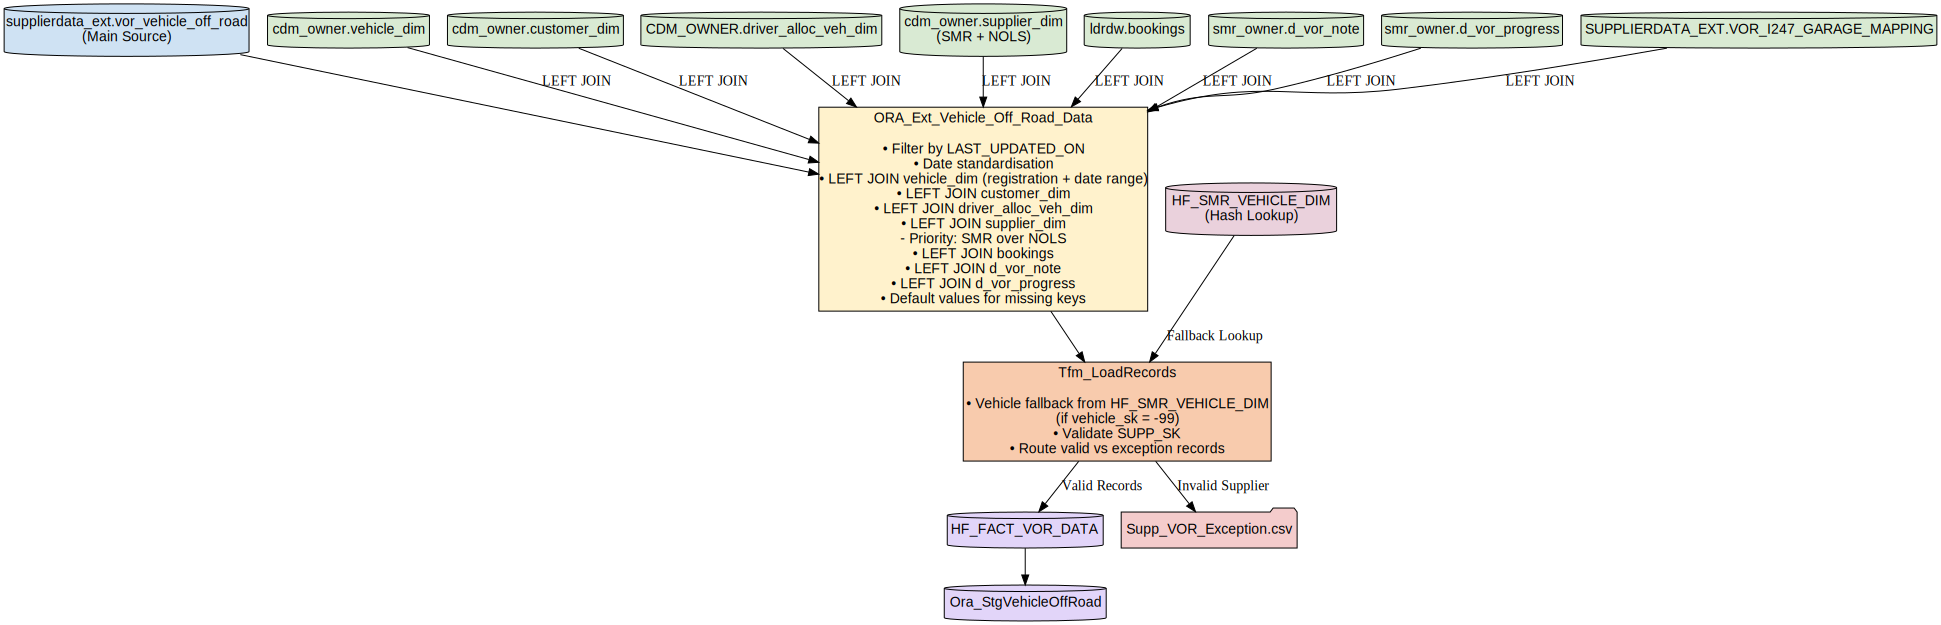

In [10]:
import graphviz

dot_code_5 = """
digraph VOR_Medium_Architecture {

    rankdir=TB;
    fontname="Helvetica";
    fontsize=10;
    node [fontname="Helvetica"];

    /* =========================
       PRIMARY SOURCE
    ========================= */

    node [shape=cylinder, style=filled, fillcolor="#CFE2F3"];
    VOR_SRC [label="supplierdata_ext.vor_vehicle_off_road\n(Main Source)"];

    /* =========================
       DIMENSION TABLES
    ========================= */

    node [shape=cylinder, style=filled, fillcolor="#D9EAD3"];
    VEH_DIM [label="cdm_owner.vehicle_dim"];
    CUST_DIM [label="cdm_owner.customer_dim"];
    DRIVER_DIM [label="CDM_OWNER.driver_alloc_veh_dim"];
    SUPP_DIM [label="cdm_owner.supplier_dim\n(SMR + NOLS)"];
    BOOKINGS [label="ldrdw.bookings"];
    NOTE_DIM [label="smr_owner.d_vor_note"];
    PROG_DIM [label="smr_owner.d_vor_progress"];
    GARAGE_MAP [label="SUPPLIERDATA_EXT.VOR_I247_GARAGE_MAPPING"];

    /* =========================
       EXTRACTION + JOIN LOGIC
    ========================= */

    node [shape=box, style=filled, fillcolor="#FFF2CC"];
    EXTRACTION [label="ORA_Ext_Vehicle_Off_Road_Data\n\n• Filter by LAST_UPDATED_ON\n• Date standardisation\n• LEFT JOIN vehicle_dim (registration + date range)\n• LEFT JOIN customer_dim\n• LEFT JOIN driver_alloc_veh_dim\n• LEFT JOIN supplier_dim\n  - Priority: SMR over NOLS\n• LEFT JOIN bookings\n• LEFT JOIN d_vor_note\n• LEFT JOIN d_vor_progress\n• Default values for missing keys"];

    /* =========================
       TRANSFORMATION
    ========================= */

    node [shape=box, style=filled, fillcolor="#F8CBAD"];
    TRANSFORM [label="Tfm_LoadRecords\n\n• Vehicle fallback from HF_SMR_VEHICLE_DIM\n  (if vehicle_sk = -99)\n• Validate SUPP_SK\n• Route valid vs exception records"];

    /* =========================
       HASH LOOKUP
    ========================= */

    node [shape=cylinder, style=filled, fillcolor="#EAD1DC"];
    VEH_HASH [label="HF_SMR_VEHICLE_DIM\n(Hash Lookup)"];

    /* =========================
       TARGET TABLES
    ========================= */

    node [shape=cylinder, style=filled, fillcolor="#E2D5F9"];
    FACT_TABLE [label="HF_FACT_VOR_DATA"];
    STAGE_TABLE [label="Ora_StgVehicleOffRoad"];

    /* =========================
       EXCEPTION FILE
    ========================= */

    node [shape=folder, style=filled, fillcolor="#F4CCCC"];
    EXCEPTION_FILE [label="Supp_VOR_Exception.csv"];

    /* =========================
       DATA FLOW
    ========================= */

    VOR_SRC -> EXTRACTION;

    VEH_DIM -> EXTRACTION [label="LEFT JOIN"];
    CUST_DIM -> EXTRACTION [label="LEFT JOIN"];
    DRIVER_DIM -> EXTRACTION [label="LEFT JOIN"];
    SUPP_DIM -> EXTRACTION [label="LEFT JOIN"];
    BOOKINGS -> EXTRACTION [label="LEFT JOIN"];
    NOTE_DIM -> EXTRACTION [label="LEFT JOIN"];
    PROG_DIM -> EXTRACTION [label="LEFT JOIN"];
    GARAGE_MAP -> EXTRACTION [label="LEFT JOIN"];

    EXTRACTION -> TRANSFORM;

    VEH_HASH -> TRANSFORM [label="Fallback Lookup"];

    TRANSFORM -> FACT_TABLE [label="Valid Records"];
    FACT_TABLE -> STAGE_TABLE;

    TRANSFORM -> EXCEPTION_FILE [label="Invalid Supplier"];
}
"""

graphviz.Source(dot_code_5)

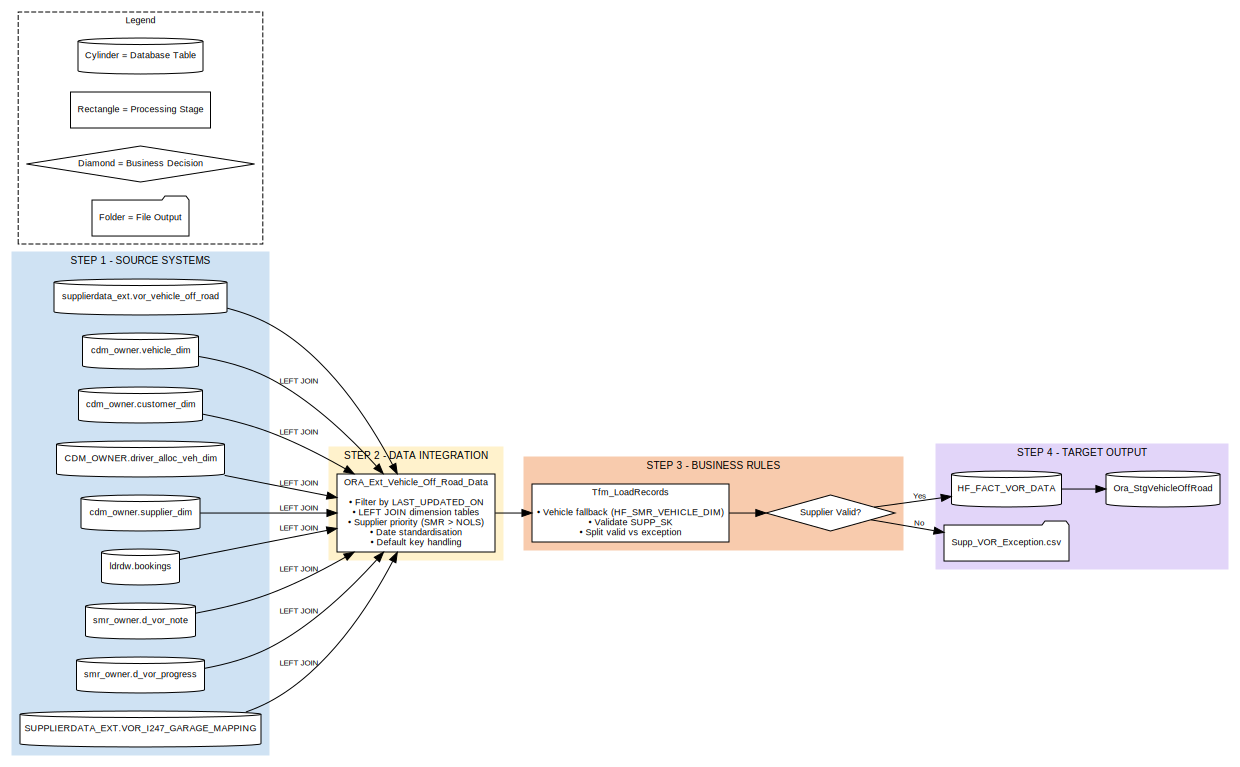

In [12]:
import graphviz

dot_code_6 = """
digraph VOR_CIO_Architecture {

    rankdir=LR;
    fontsize=10;
    fontname="Helvetica";
    node [fontname="Helvetica", fontsize=9];
    edge [fontname="Helvetica", fontsize=8];

    /* =====================================================
       STEP 1 - SOURCE LAYER
    ===================================================== */

    subgraph cluster_source {
        label="STEP 1 - SOURCE SYSTEMS";
        style=filled;
        color="#CFE2F3";
        fillcolor="#CFE2F3";

        node [shape=cylinder, style=filled, fillcolor="white"];

        VOR_SRC [label="supplierdata_ext.vor_vehicle_off_road"];
        VEH_DIM [label="cdm_owner.vehicle_dim"];
        CUST_DIM [label="cdm_owner.customer_dim"];
        DRIVER_DIM [label="CDM_OWNER.driver_alloc_veh_dim"];
        SUPP_DIM [label="cdm_owner.supplier_dim"];
        BOOKINGS [label="ldrdw.bookings"];
        NOTE_DIM [label="smr_owner.d_vor_note"];
        PROG_DIM [label="smr_owner.d_vor_progress"];
        GARAGE_MAP [label="SUPPLIERDATA_EXT.VOR_I247_GARAGE_MAPPING"];
    }

    /* =====================================================
       STEP 2 - DATA INTEGRATION
    ===================================================== */

    subgraph cluster_integration {
        label="STEP 2 - DATA INTEGRATION";
        style=filled;
        color="#FFF2CC";
        fillcolor="#FFF2CC";

        node [shape=box, style=filled, fillcolor="white"];

        EXTRACTION [label="ORA_Ext_Vehicle_Off_Road_Data\n\n• Filter by LAST_UPDATED_ON\n• LEFT JOIN dimension tables\n• Supplier priority (SMR > NOLS)\n• Date standardisation\n• Default key handling"];
    }

    /* =====================================================
       STEP 3 - BUSINESS RULES
    ===================================================== */

    subgraph cluster_business {
        label="STEP 3 - BUSINESS RULES";
        style=filled;
        color="#F8CBAD";
        fillcolor="#F8CBAD";

        node [shape=box, style=filled, fillcolor="white"];

        TRANSFORM [label="Tfm_LoadRecords\n\n• Vehicle fallback (HF_SMR_VEHICLE_DIM)\n• Validate SUPP_SK\n• Split valid vs exception"];

        DECISION [shape=diamond, label="Supplier Valid?"];
    }

    /* =====================================================
       STEP 4 - TARGET LAYER
    ===================================================== */

    subgraph cluster_target {
        label="STEP 4 - TARGET OUTPUT";
        style=filled;
        color="#E2D5F9";
        fillcolor="#E2D5F9";

        node [shape=cylinder, style=filled, fillcolor="white"];

        FACT_TABLE [label="HF_FACT_VOR_DATA"];
        STAGE_TABLE [label="Ora_StgVehicleOffRoad"];

        node [shape=folder, style=filled, fillcolor="white"];
        EXCEPTION_FILE [label="Supp_VOR_Exception.csv"];
    }

    /* =====================================================
       DATA FLOW
    ===================================================== */

    /* Source to Integration */
    VOR_SRC -> EXTRACTION;

    VEH_DIM -> EXTRACTION [label="LEFT JOIN"];
    CUST_DIM -> EXTRACTION [label="LEFT JOIN"];
    DRIVER_DIM -> EXTRACTION [label="LEFT JOIN"];
    SUPP_DIM -> EXTRACTION [label="LEFT JOIN"];
    BOOKINGS -> EXTRACTION [label="LEFT JOIN"];
    NOTE_DIM -> EXTRACTION [label="LEFT JOIN"];
    PROG_DIM -> EXTRACTION [label="LEFT JOIN"];
    GARAGE_MAP -> EXTRACTION [label="LEFT JOIN"];

    /* Integration to Business */
    EXTRACTION -> TRANSFORM;

    /* Business Rule Split */
    TRANSFORM -> DECISION;
    DECISION -> FACT_TABLE [label="Yes"];
    DECISION -> EXCEPTION_FILE [label="No"];

    FACT_TABLE -> STAGE_TABLE;

    /* =====================================================
       LEGEND
    ===================================================== */

    subgraph cluster_legend {
        label="Legend";
        fontsize=9;
        style=dashed;

        LEG1 [shape=cylinder, label="Cylinder = Database Table"];
        LEG2 [shape=box, label="Rectangle = Processing Stage"];
        LEG3 [shape=diamond, label="Diamond = Business Decision"];
        LEG4 [shape=folder, label="Folder = File Output"];
    }
}
"""

graphviz.Source(dot_code_6)